# Model 2: Decision Tree
**CAP182 Capstone Project: STADIOEquities**

Inputs: `data/train.csv`, `data/test.csv` and `models/preprocessor.pkl` (created by `feature-extraction/feature_engineering.ipynb`).
Outputs: `models/model2_decision_tree.pkl`, `evaluation/model2_decision_tree_results.csv` and charts in `modelling/figures/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)
os.makedirs("../evaluation", exist_ok=True)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
X_train, y_train = train.drop(columns="y"), train["y"]
X_test, y_test = test.drop(columns="y"), test["y"]
preprocessor = joblib.load("../models/preprocessor.pkl")
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (32940, 19)  Test: (8236, 19)


## 1. Training and hyperparameter tuning
`class_weight="balanced"` handles the class imbalance (about 6% "yes" in the training period). Hyperparameters are tuned with grid search and 5-fold stratified cross-validation **within the training period only**, using ROC AUC as the tuning metric. The test period is not used for tuning.

In [2]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_SEED)),
])
param_grid = {"model__max_depth": [3, 4, 5, 6, 8], "model__min_samples_leaf": [20, 50, 100]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
search = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
search.fit(X_train, y_train)
model = search.best_estimator_

print("Best hyperparameters:", search.best_params_)
print(f"Cross-validation AUC: {search.best_score_:.3f}")

Best hyperparameters: {'model__max_depth': 8, 'model__min_samples_leaf': 100}
Cross-validation AUC: 0.665


## 2. Evaluation on the unseen (later) test period

In [3]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame([{
    "Algorithm": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_prob),
}]).set_index("Algorithm").round(3)
results.to_csv("../evaluation/model2_decision_tree_results.csv")
results

,Accuracy,Precision,Recall,F1-Score,AUC
Algorithm,,,,,
Decision Tree,0.42,0.306,0.693,0.424,0.552


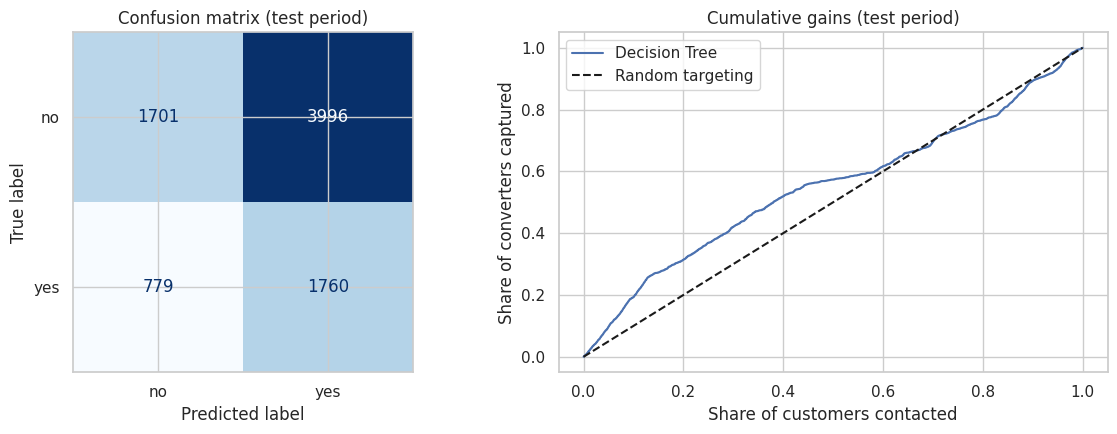

Top 20% of ranked customers captures 31.4% of converters


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no", "yes"],
                                        cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix (test period)")

order = np.argsort(-y_prob)
gains = np.cumsum(y_test.values[order]) / y_test.sum()
pct = np.arange(1, len(gains) + 1) / len(gains)
axes[1].plot(pct, gains, label="Decision Tree")
axes[1].plot([0, 1], [0, 1], "k--", label="Random targeting")
axes[1].set_xlabel("Share of customers contacted"); axes[1].set_ylabel("Share of converters captured")
axes[1].set_title("Cumulative gains (test period)"); axes[1].legend()
plt.tight_layout(); plt.savefig("figures/model2_decision_tree_evaluation.png", dpi=150); plt.show()
print(f"Top 20% of ranked customers captures {gains[int(0.2 * len(gains)) - 1]:.1%} of converters")

## 3. Model interpretation
Feature importance shows how much each feature contributed to the tree's splits. Importances sum to 1 and have no direction.

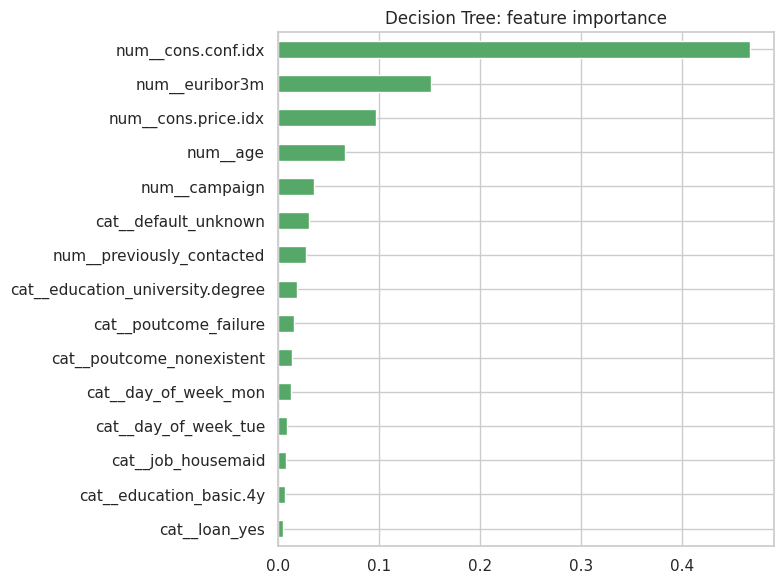

num__cons.conf.idx                  0.467
num__euribor3m                      0.151
num__cons.price.idx                 0.097
num__age                            0.066
num__campaign                       0.036
cat__default_unknown                0.030
num__previously_contacted           0.027
cat__education_university.degree    0.018
cat__poutcome_failure               0.016
cat__poutcome_nonexistent           0.013
cat__day_of_week_mon                0.013
cat__day_of_week_tue                0.008
cat__job_housemaid                  0.008
cat__education_basic.4y             0.007
cat__loan_yes                       0.005
dtype: float64

In [5]:
feat_names = model.named_steps["prep"].get_feature_names_out()
imp = pd.Series(model.named_steps["model"].feature_importances_, index=feat_names)
imp = imp[imp > 0].sort_values(ascending=False).head(15)

ax = imp.sort_values().plot(kind="barh", figsize=(8, 6), color="#55A868")
ax.set_title("Decision Tree: feature importance")
plt.tight_layout(); plt.savefig("figures/model2_importance.png", dpi=150); plt.show()
imp.round(3)

## 4. Robustness check: random stratified split
For comparison only. The same tuned model is retrained on a shuffled, stratified split to show how much performance depends on the change over time. `clone` creates a fresh copy so the tuned model above is not overwritten.

In [6]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    pd.concat([X_train, X_test]), pd.concat([y_train, y_test]),
    test_size=0.2, stratify=pd.concat([y_train, y_test]), random_state=RANDOM_SEED)
random_model = clone(model).fit(Xr_train, yr_train)
print(f"AUC, time-ordered split: {results['AUC'].iloc[0]:.3f}")
print(f"AUC, random split:       {roc_auc_score(yr_test, random_model.predict_proba(Xr_test)[:, 1]):.3f}")

AUC, time-ordered split: 0.552
AUC, random split:       0.799


## 5. Save the trained model
The full pipeline (preprocessing and model) is saved, so it can be used on new data without retraining.

In [7]:
joblib.dump(model, "../models/model2_decision_tree.pkl")
print("Saved ../models/model2_decision_tree.pkl")

Saved ../models/model2_decision_tree.pkl


## 6. Inference: using the saved model on new customers
This shows how to load the saved model and predict for new records. Here the first five test-period customers stand in for new data; any data with the same columns as `data/train.csv` (without `y`) can be used.

In [8]:
loaded_model = joblib.load("../models/model2_decision_tree.pkl")

new_customers = X_test.head(5)
predictions = pd.DataFrame({
    "Probability of conversion": loaded_model.predict_proba(new_customers)[:, 1].round(3),
    "Predicted class (1 = yes)": loaded_model.predict(new_customers),
    "Actual": y_test.head(5).values,
})
predictions

,Probability of conversion,Predicted class (1 = yes),Actual
0,0.528,1,0
1,0.535,1,0
2,0.370,0,0
3,0.528,1,0
4,0.370,0,0


## 7. Comparison with Model 1
Requires `modelling/model1_logistic_regression.ipynb` to have been run first.

In [9]:
comparison = pd.concat([pd.read_csv("../evaluation/model1_logistic_regression_results.csv", index_col=0), results])
comparison.to_csv("../evaluation/model_comparison.csv")
comparison

,Accuracy,Precision,Recall,F1-Score,AUC
Algorithm,,,,,
Logistic Regression,0.45,0.352,0.932,0.511,0.741
Decision Tree,0.42,0.306,0.693,0.424,0.552
